Benjamin Arnold; 10/04/2026; Lab 6: Spinning and Rolling Objects

Part A-- The Physical Pendulum

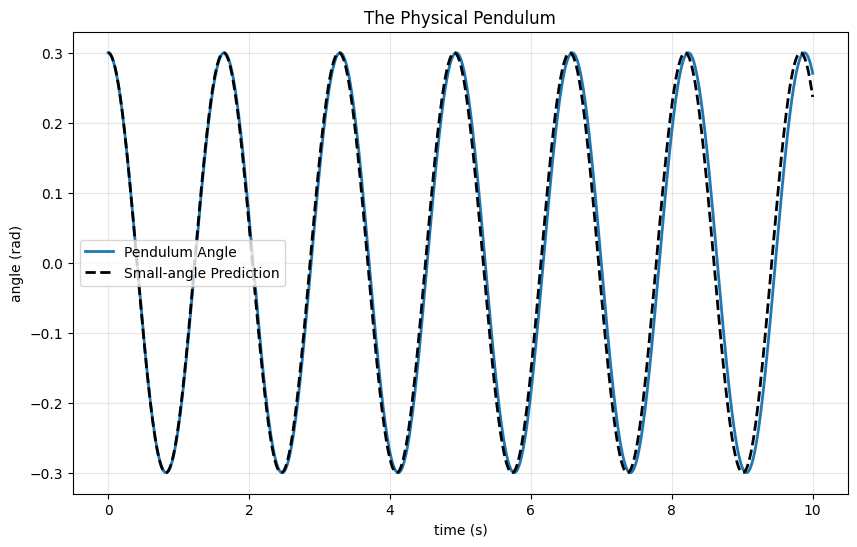

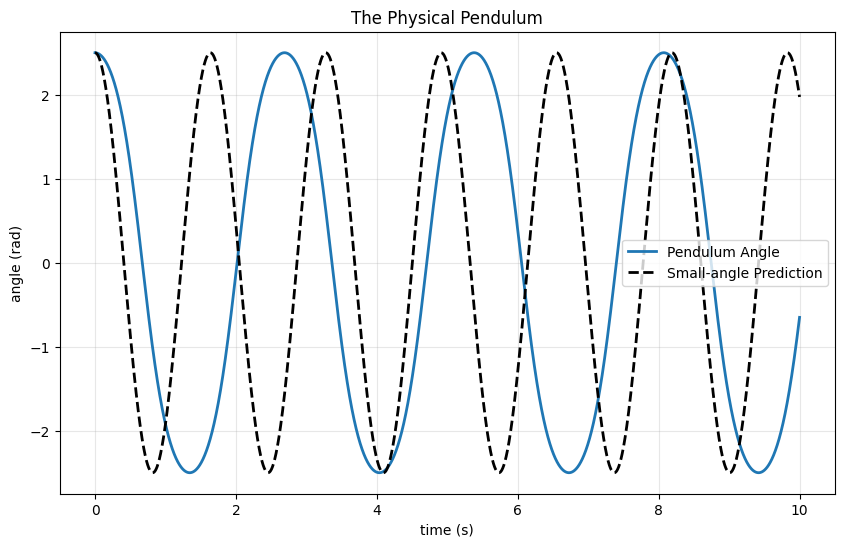

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def moment_of_inertia(masses,positions,axis):
    total=0.0
    for m,r in zip(masses,positions):
        total+=m*np.sum((np.asarray(r)-np.asarray(axis))**2)
    return total

def rotate_step(theta,omega,torque,I,dt):
    alpha=torque/I
    omega=omega+alpha*dt
    theta=theta+omega*dt
    return theta,omega

m,g,d=1.0,9.81,0.5
I =(1/3)*m*(2*d)**2 
def torque(theta):
    return -m*g*d*np.sin(theta)

t=np.linspace(0,10,10000)
def small_angle_prediction(theta,t):
    omega=np.sqrt(m*g*d/I)
    return theta*np.cos(omega*t)

phi=small_angle_prediction(0.3,t)

theta,omega=0.3,0.0
dt=0.001
theta_arr=[]
for _ in range(10000):
    theta,omega=rotate_step(theta,omega,torque(theta),I,dt)
    theta_arr.append(theta)

plt.figure(figsize=(10, 6))
plt.plot(t, theta_arr, linewidth=2, label='Pendulum Angle')
plt.plot(t, phi, linewidth=2, linestyle='--', color='black', label='Small-angle Prediction')
plt.xlabel('time (s)')
plt.ylabel('angle (rad)')
plt.title('The Physical Pendulum')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

phi=small_angle_prediction(2.5,t)

theta,omega=2.5,0.0
dt=0.001
theta_arr=[]
for _ in range(10000):
    theta,omega=rotate_step(theta,omega,torque(theta),I,dt)
    theta_arr.append(theta)

plt.figure(figsize=(10, 6))
plt.plot(t, theta_arr, linewidth=2, label='Pendulum Angle')
plt.plot(t, phi, linewidth=2, linestyle='--', color='black', label='Small-angle Prediction')
plt.xlabel('time (s)')
plt.ylabel('angle (rad)')
plt.title('The Physical Pendulum')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Note: At a large amplitude, the real period is longer than what the small-angle equation predicts. In previous labs, we saw something similar with nonlinear pendula. At large angles, phase space is distorted such than motion is no longer sinusoidal. Here, the torque makes the equations of motion nonlinear so that again phase space is no longer circular, resulting in a period different from the small-angle prediction.

Part B-- The Rolling Race

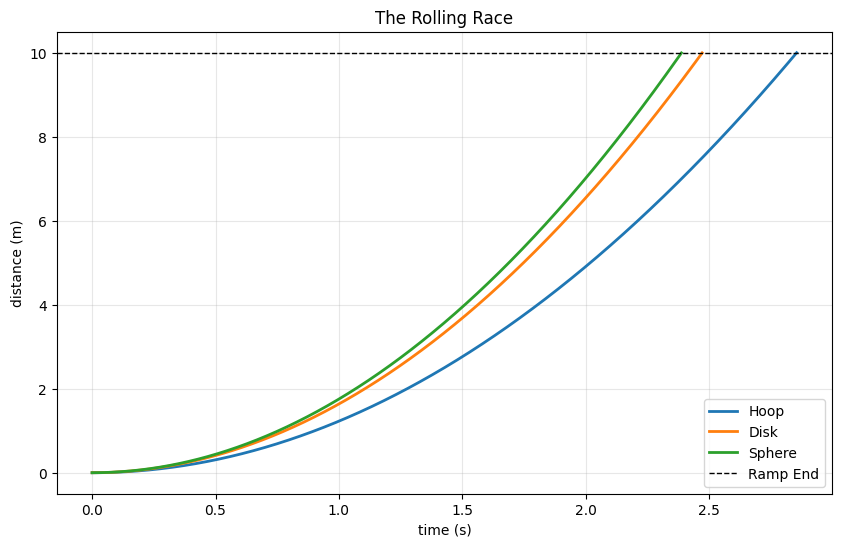

Race Results: The sphere is 1st at 2.39s, the disk is 2nd at 2.47s, and the hoop is 3rd at 2.85s.


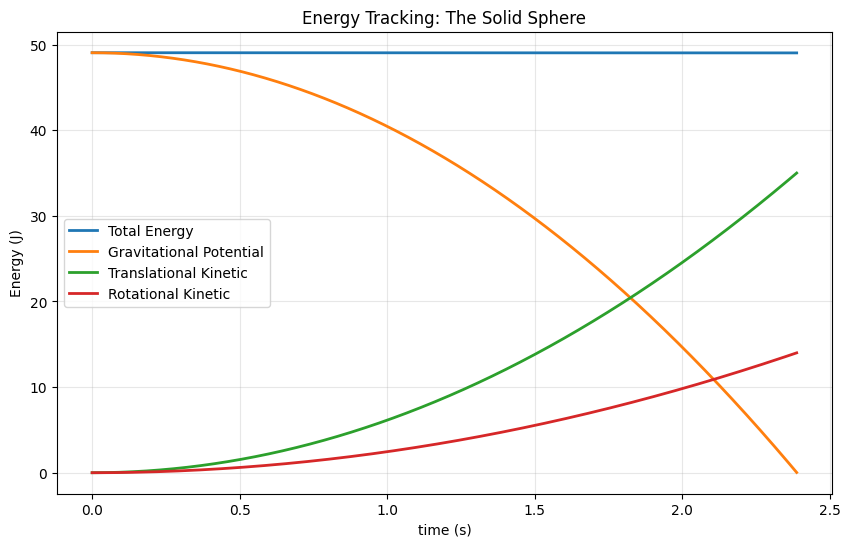

By the end of the race, the sphere has 28.55% of its total energy as rotational.


In [41]:
def rolling_accel(theta_incline,c,g=9.81):
    return g*np.sin(theta_incline)/(1+c)

ramp_length=10
theta_incline=30*(np.pi/180)
dt=0.001
def EulerCromer_step(r,v,c,dt,g):
    a=rolling_accel(theta_incline,c,g)

    v_new=v+a*dt
    r_new=r+v_new*dt
    return r_new, v_new

def race(c):
    r_arr=[]
    t_arr=[]
    v_arr=[]
    r,v=0.0,0.0
    t=0.0
    
    while r<=ramp_length:
        r_arr.append(r)
        t_arr.append(t)
        v_arr.append(v)
        r,v=EulerCromer_step(r,v,c,dt,9.81)
        t=t+dt
        
    return t_arr,r_arr,v_arr

t_hoop,r_hoop,v_hoop=race(1.0)
t_disk,r_disk,v_disk=race(0.5)
t_sphere,r_sphere,v_sphere=race(0.4)

plt.figure(figsize=(10, 6))
plt.plot(t_hoop, r_hoop, linewidth=2, label='Hoop')
plt.plot(t_disk, r_disk, linewidth=2, label='Disk')
plt.plot(t_sphere, r_sphere, linewidth=2, label='Sphere')
plt.axhline(y=ramp_length, color='black', linestyle='--', linewidth=1, label='Ramp End')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.title('The Rolling Race')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f'Race Results: The sphere is 1st at {t_sphere[-1]:.2f}s, the disk is 2nd at {t_disk[-1]:.2f}s, and the hoop is 3rd at {t_hoop[-1]:.2f}s.')

t_sphere,r_sphere,v_sphere=np.array(t_sphere),np.array(r_sphere),np.array(v_sphere)
h_initial=ramp_length*np.sin(theta_incline)
def energy(r,v,c,m):
    K_trans=0.5*m*v**2
    K_rot=0.5*c*m*v**2
    P_grav=g*(h_initial-r*np.sin(theta_incline))
    E_total=P_grav+K_rot+K_trans
    return E_total,P_grav,K_trans,K_rot

E_total,P_grav,K_trans,K_rot=energy(r_sphere,v_sphere,0.4,1.0)

plt.figure(figsize=(10, 6))
plt.plot(t_sphere, E_total, linewidth=2, label='Total Energy')
plt.plot(t_sphere, P_grav, linewidth=2, label='Gravitational Potential')
plt.plot(t_sphere, K_trans, linewidth=2, label='Translational Kinetic')
plt.plot(t_sphere, K_rot, linewidth=2, label='Rotational Kinetic')
plt.xlabel('time (s)')
plt.ylabel('Energy (J)')
plt.title('Energy Tracking: The Solid Sphere')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f'By the end of the race, the sphere has {(K_rot[-1]/E_total[-1])*100:.2f}% of its total energy as rotational.')

Notes: Mass cancels because gravitational potential energy, rotational, and translational kinetic energy are all linearly proportional to mass. Since these are the components of total energy (and because in the beginning, E=PE), one can divide across, cancelling mass entirely. 

Part C-- Angular Momentum Conservation

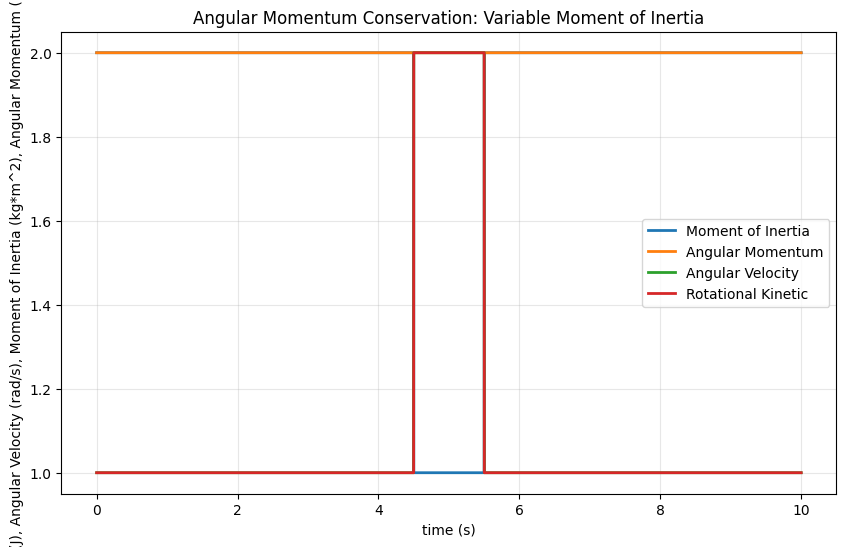

In [ ]:
I_0,L=2.0,2.0
theta,omega=1.0,1.0
dt=0.001

theta_arr=[]
omega_arr=[]
I_arr=[]
L_arr=[]
K_rot_arr=[]

for step in range(10000):
    if 4500<=step<=5500:
        I=I_0/2.0
    else:
        I=I_0
    
    omega=L/I
    K=0.5*I*omega**2

    theta_arr.append(theta)
    omega_arr.append(omega)
    I_arr.append(I)
    L_arr.append(L)
    K_rot_arr.append(K)

    theta,omega=rotate_step(theta,omega,0.0,I,dt)

t=np.linspace(0,10,10000)

plt.figure(figsize=(10, 6))
plt.plot(t, I_arr, linewidth=2, label='Moment of Inertia')
plt.plot(t, L_arr, linewidth=2, label='Angular Momentum')
plt.plot(t, omega_arr, linewidth=2, label='Angular Velocity')
plt.plot(t, K_rot_arr, linewidth=2, label='Rotational Kinetic')
plt.xlabel('time (s)')
plt.ylabel('Energy (J), Angular Velocity (rad/s), Moment of Inertia (kg*m^2), Angular Momentum (kg*m^2/s)')
plt.title('Angular Momentum Conservation: Variable Moment of Inertia')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Note: The extra KE comes from the change in the moment of inertia, and this can only come from work from within the rotating body. The work done is the reason this does not violate energy conservation. In the figure skater example, the chemical energy within her muscles is expended so that her arms can go inward, reducing her moment of inertia and increasing her angular velocity. Energy is conserved because the rotational energy gained is balanced by that chemical expenditure in her muscles. 

Bringing it together:
1. Energy Conservation: This law can track bugs relating to how the simulation calculates steps. For example, we looked at Euler, Euler-Cromer and Verlet steps, and we saw how Euler steps cause energy to increase without physical cause. If we want to find some other ingenious method of updating our simulation, then confirming energy conservation would prove that method.
2. Linear Momentum Conservation: This law can help us to catch errors in how forces change momentum vectors. For example, when we looked at the colliding balls in a previous lab, we had to be careful with our vectors and the equations which calculated them. If total momentum anomalously increased in the simulation, then we know our calculations were off. Alternatively, we might have an infinite-mass wall or something else. 
3. Angular Momentum Conservation: This law can help ensure momentum vectors have proper direction throught the simulation. If there is an error in their calculation, then it will appear in the total angular momentum, which will be quite sensitive especially for many bodys.